In [ ]:
# ============================================================
# OUROBOROS PROYECT — CONSULTORA DE VIDEOJUEGOS
# Ciencia de Datos | Dataset: Top 500 juegos de Steam
# ============================================================

# ============================================================
# BLOQUE 0 — LIBRERÍAS E IMPORTACIÓN DEL DATASET
# ============================================================
# Por qué está acá: todo notebook arranca importando las
# herramientas y cargando los datos. Es la base de todo.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import os

def currency_formatter(x, pos):
    if x >= 1e9:
        return f'${x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.1f}K'
    else:
        return f'${int(x)}'

def player_formatter(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    else:
        return f'{int(x)}'

# Lista de archivos CSV requeridos
required_csv_files = [
    "steam_games_2026_500.csv",
    "games_dataset.csv",
    "steamdb_game_releases_per_year.csv",
    "windows-10-icon-seeklogo.png",
    "apple-seeklogo.png",
    "linux-tux-seeklogo.png"
]

# Verificar si todos los archivos requeridos existen localmente
all_files_exist = True
for file_name in required_csv_files:
    if not os.path.exists(file_name):
        all_files_exist = False
        break

# Si falta algún archivo, pedir al usuario que los cargue
if not all_files_exist:
    print("Falta uno o más archivos requeridos. Por favor, cárguelos:")
    uploaded = files.upload()
    if uploaded: # Check if files were actually uploaded
        print("Archivos subidos:", uploaded.keys())
else:
    print("Todos los archivos requeridos ya están presentes. Saltando la carga.")
    uploaded = {} # Inicializar 'uploaded' como un diccionario vacío si no se realizó la carga

df1 = pd.read_csv("steam_games_2026_500.csv", encoding='Windows-1252', sep=';', decimal=',')
df2 = pd.read_csv("games_dataset.csv", encoding='utf-8', sep=',', decimal=',')
df3 = pd.read_csv('steamdb_game_releases_per_year.csv', encoding='UTF-8-SIG', sep=';')

print("Dataset cargado correctamente")
print(f"Filas: {df1.shape[0]} | Columnas: {df1.shape[1]}")
print(df1.columns.tolist())
print(f"Filas: {df2.shape[0]} | Columnas: {df2.shape[1]}")
print(df2.columns.tolist())
print(f"Filas: {df3.shape[0]} | Columnas: {df3.shape[1]}")
print(df3.columns.tolist())

Todos los archivos requeridos ya están presentes. Saltando la carga.
Dataset cargado correctamente
Filas: 500 | Columnas: 13
['AppID', 'Name', 'Release_Date', 'Primary_Genre', 'All_Tags', 'Price_USD', 'Review_Score_Pct_SteamDB', 'Total_Reviews', 'Positive_Reviews', 'Steam_Deck_Status', 'Estimated_Owners', '24h_Peak_Players', 'Is_DLC?']
Filas: 50872 | Columnas: 13
['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']
Filas: 21 | Columnas: 3
['DateTime', 'Games', 'Limited Games']


In [ ]:
# ============================================================
# BLOQUE 1 — LIMPIEZA Y PREPARACIÓN DEL DATASET
# ============================================================
# Por qué está acá: los datos crudos siempre tienen problemas.
# Este bloque toma decisiones explícitas sobre qué incluir y
# qué no, y las justifica. Así el análisis siguiente es confiable.
#
# Preguntas que responde:
#   - ¿Qué tan completo es el dataset?
#   - ¿Cómo manejamos los juegos gratis (Price = 0)?
#   - ¿Qué hacemos con juegos sin reviews?

# Filtrar juegos que no son DLCs
df1 = df1[df1['Is_DLC?'] == 'No'].copy()

# Definición de ARPU base por género
ARPU_base = {"Action": 13, "Adventure": 9, "RPG": 20, "Strategy": 13, "Simulation": 8, "Casual": 6, "Massively Multiplayer": 22, "Indie": 7, "Sports": 11, "Racing": 9, "Unknown": 10}

# Crear la columna ARPU en el DataFrame principal 'df'
df1['ARPU'] = df1['Primary_Genre'].map(ARPU_base)

# Si algún género no estuviera en ARPU_base, su ARPU se establecería en NaN.
# Por seguridad, podemos llenar esos valores con el ARPU de 'Unknown'.
df1['ARPU'].fillna(value=ARPU_base['Unknown'], inplace=True)

# Crear la columna ADPG (Average Discount Per Game) - Vuelve a la lógica simple
df1['ADPG'] = df1['Price_USD'].apply(lambda x: 0.3 if x > 0 else 0)

# --- Nueva lógica para ADPC (Average Distribution Platform Cut) basada en Revenue Bruto Total por tramos ---

# 1. Calcular el Revenue Bruto Total para cada juego (base para el corte de plataforma)
# Para juegos de pago: Estimated_Owners * Price_USD
# Para juegos gratuitos: Estimated_Owners * ARPU
df1['Gross_Revenue_Total'] = df1.apply(
    lambda row: (row['Estimated_Owners'] * row['Price_USD']) if row['Price_USD'] > 0
    else (row['Estimated_Owners'] * row['ARPU']),
    axis=1
)

# 2. Definir función para calcular el ADPC efectivo basado en los tramos
def calculate_effective_adpc(gross_revenue_total):
    if gross_revenue_total <= 0:
        return 0.0 # No hay corte de plataforma para juegos sin revenue

    # Los tramos se aplican sobre el Revenue Bruto Total
    net_revenue_after_adpc = 0
    remaining_gross = gross_revenue_total

    # Tramo 3: por encima de 50M, corte 0.2 (factor neto 0.8)
    if remaining_gross > 50_000_000:
        net_revenue_after_adpc += (remaining_gross - 50_000_000) * (1 - 0.2)
        remaining_gross = 50_000_000

    # Tramo 2: de 10M a 50M, corte 0.25 (factor neto 0.75)
    if remaining_gross > 10_000_000:
        net_revenue_after_adpc += (remaining_gross - 10_000_000) * (1 - 0.25)
        remaining_gross = 10_000_000

    # Tramo 1: hasta 10M, corte 0.3 (factor neto 0.7)
    net_revenue_after_adpc += remaining_gross * (1 - 0.3)

    # El ADPC efectivo es 1 menos el ratio de Revenue Neto sobre Revenue Bruto Total
    return 1 - (net_revenue_after_adpc / gross_revenue_total)

# 3. Aplicar la función para crear la columna ADPC
df1['ADPC'] = df1['Gross_Revenue_Total'].apply(calculate_effective_adpc)

# Calculate positive_ratio from Positive_Reviews and Total_Reviews in df1
# Handle division by zero: if Total_Reviews is 0, positive_ratio should be 0.
df1['positive_ratio'] = df1.apply(
    lambda row: (row['Positive_Reviews'] / row['Total_Reviews']) * 100 if row['Total_Reviews'] > 0 else 0,
    axis=1
)

print("=== ANÁLISIS DE VALORES NULOS ===")
print(df1.isnull().sum())

print("\n=== DISTRIBUCIÓN DE PRECIOS ===")
print(f"Juegos gratuitos (Price = 0): {(df1['Price_USD'] == 0).sum()}")
print(f"Juegos de pago (Price > 0):   {(df1['Price_USD'] > 0).sum()}")
print(f"Juegos sin reviews:           {(df1['Total_Reviews'] == 0).sum()}")

# --- Decisión de limpieza ---
# Para el análisis de revenue, creamos una columna 'Revenue' que considera:
# - Para juegos de pago: Estimated_Owners * Price_USD * (1 - ADPG) * (1 - ADPC) (Net Revenue)
# - Para juegos gratuitos: Estimated_Owners * ARPU * (1 - ADPC) (promedio de revenue por usuario)
# Filtramos para incluir solo juegos que tienen al menos una review.

juegos_de_pago = df1[df1['Price_USD'] > 0].copy()

# Crear un DataFrame para el análisis de revenue que incluya todos los juegos con reviews
df1_revenue_analysis = df1[df1['Total_Reviews'] > 0].copy()

# Calcular la columna 'Revenue' en este nuevo DataFrame
df1_revenue_analysis['Revenue'] = df1_revenue_analysis.apply(
    lambda row: (row['Estimated_Owners'] * row['Price_USD'] * (1 - row['ADPG']) * (1 - row['ADPC'])) if row['Price_USD'] > 0
    else row['Estimated_Owners'] * row['ARPU'] * (1 - row['ADPC']),
    axis=1
)

# Actualizar 'juegos_con_revenue' para que apunte a este nuevo DataFrame
juegos_con_revenue = df1_revenue_analysis

print(f"\nDataset para análisis de revenue: {juegos_con_revenue.shape[0]} juegos")

print("\n=== EJEMPLOS DE CÁLCULO DE ADPG, ADPC y REVENUE (primeros 5 juegos de pago) ===")
sample_games = df1_revenue_analysis[df1_revenue_analysis['Price_USD'] > 0].head(5).copy()
sample_games['Gross_Revenue_Paid'] = sample_games['Estimated_Owners'] * sample_games['Price_USD']
sample_games['Gross_Revenue_Total'] = sample_games.apply(
    lambda row: (row['Estimated_Owners'] * row['Price_USD']) if row['Price_USD'] > 0
    else (row['Estimated_Owners'] * row['ARPU']),
    axis=1)

print(sample_games[['Name', 'Price_USD', 'Estimated_Owners', 'Gross_Revenue_Paid', 'Gross_Revenue_Total', 'ADPG', 'ADPC', 'Revenue']].to_string())

=== ANÁLISIS DE VALORES NULOS ===
AppID                       0
Name                        0
Release_Date                0
Primary_Genre               0
All_Tags                    0
Price_USD                   0
Review_Score_Pct_SteamDB    0
Total_Reviews               0
Positive_Reviews            1
Steam_Deck_Status           0
Estimated_Owners            0
24h_Peak_Players            0
Is_DLC?                     0
ARPU                        0
ADPG                        0
Gross_Revenue_Total         0
ADPC                        0
positive_ratio              0
dtype: int64

=== DISTRIBUCIÓN DE PRECIOS ===
Juegos gratuitos (Price = 0): 58
Juegos de pago (Price > 0):   422
Juegos sin reviews:           1

Dataset para análisis de revenue: 479 juegos

=== EJEMPLOS DE CÁLCULO DE ADPG, ADPC y REVENUE (primeros 5 juegos de pago) ===
                              Name  Price_USD  Estimated_Owners  Gross_Revenue_Paid  Gross_Revenue_Total  ADPG      ADPC       Revenue
1                 S

/tmp/ipykernel_2885/3237371881.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['ARPU'].fillna(value=ARPU_base['Unknown'], inplace=True)


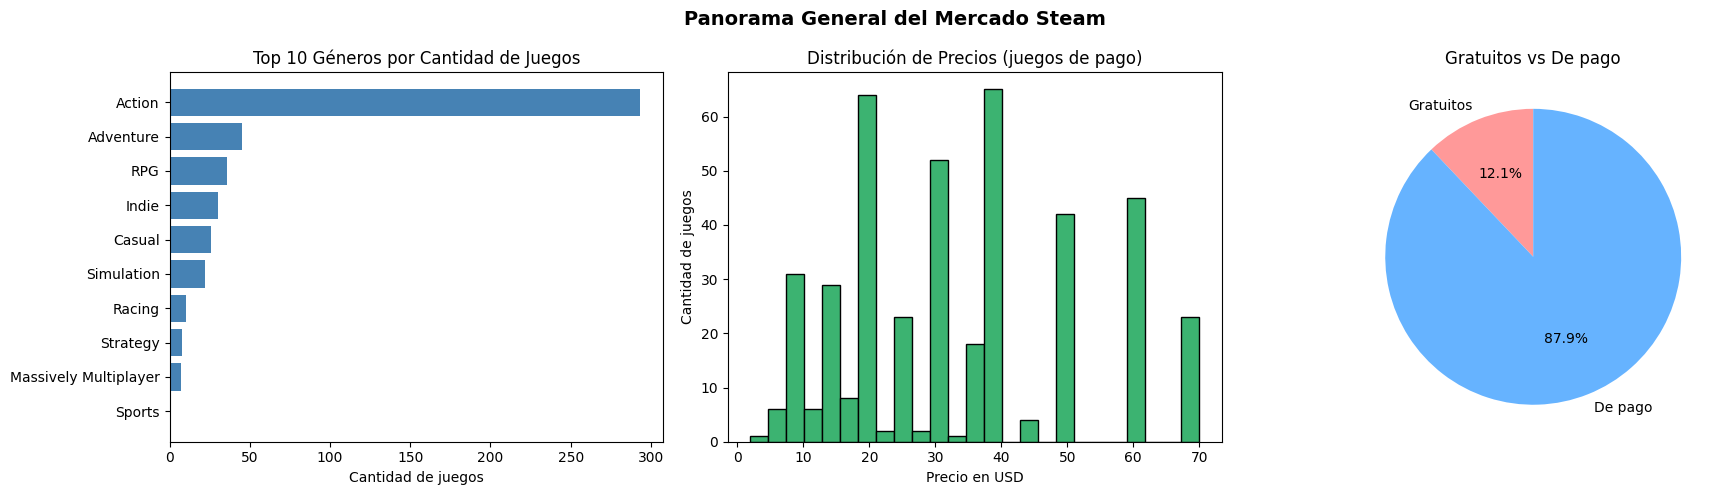

In [ ]:
# ============================================================
# BLOQUE 2 — PANORAMA GENERAL DEL MERCADO
# ============================================================
# Por qué está acá: antes de recomendar cualquier estrategia,
# una consultora necesita entender el terreno. Este bloque
# responde las preguntas básicas de contexto.
#
# Preguntas que responde:
#   - ¿Qué géneros dominan el mercado en cantidad?
#   - ¿Cómo se distribuyen los precios?
#   - ¿Qué tan grande es el mercado de juegos gratis vs de pago?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panorama General del Mercado Steam', fontsize=14, fontweight='bold')

# Gráfico 1: Top géneros por cantidad
top_generos = df1['Primary_Genre'].value_counts().head(10)
axes[0].barh(top_generos.index[::-1], top_generos.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Géneros por Cantidad de Juegos')
axes[0].set_xlabel('Cantidad de juegos')

# Gráfico 2: Distribución de precios (solo de pago)
axes[1].hist(juegos_de_pago['Price_USD'], bins=25, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribución de Precios (juegos de pago)')
axes[1].set_xlabel('Precio en USD')
axes[1].set_ylabel('Cantidad de juegos')

# Gráfico 3: Gratis vs de pago
gratis = (df1['Price_USD'] == 0).sum()
de_pago = (df1['Price_USD'] > 0).sum()
axes[2].pie([gratis, de_pago], labels=['Gratuitos', 'De pago'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
axes[2].set_title('Gratuitos vs De pago')

plt.tight_layout()
plt.show()

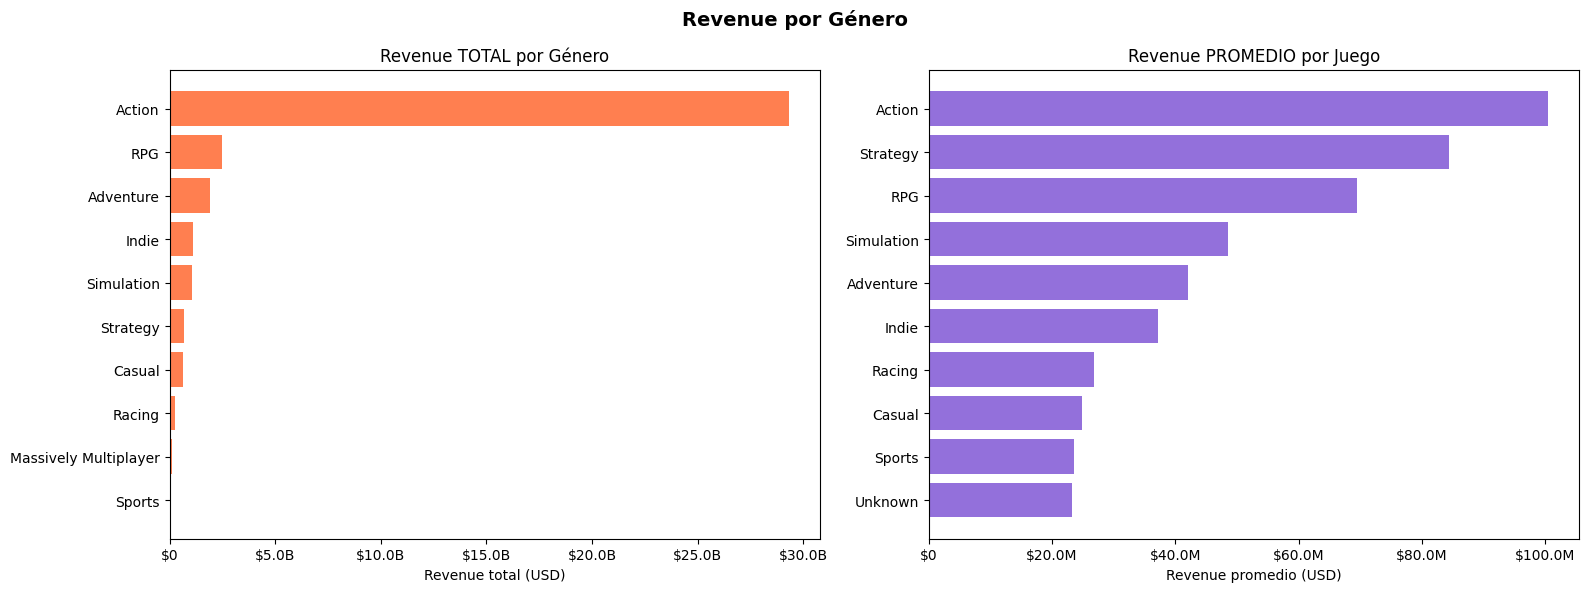

Género con mayor revenue total:   Action
Género con mayor revenue promedio: Action


In [ ]:
# ============================================================
# BLOQUE 3 — ANÁLISIS DE REVENUE POR GÉNERO
# ============================================================
# Por qué está acá: el revenue es el indicador económico central.
# Saber qué géneros generan más ingresos le dice a una empresa
# dónde conviene invertir.
#
# Preguntas que responde:
#   - ¿Qué género genera más revenue total?
#   - ¿Qué género tiene mejor revenue promedio por juego?


revenue_total = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().sort_values(ascending=False).head(10)
revenue_promedio = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue por Género', fontsize=14, fontweight='bold')

axes[0].barh(revenue_total.index[::-1], revenue_total.values[::-1], color='coral')
axes[0].set_title('Revenue TOTAL por Género')
axes[0].set_xlabel('Revenue total (USD)')
axes[0].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

axes[1].barh(revenue_promedio.index[::-1], revenue_promedio.values[::-1], color='mediumpurple')
axes[1].set_title('Revenue PROMEDIO por Juego')
axes[1].set_xlabel('Revenue promedio (USD)')
axes[1].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()

mejor_total = revenue_total.index[0]
mejor_promedio = revenue_promedio.index[0]

# Gráfico circular: Ingresos por Género Principal
revenue_by_genre = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().reset_index()

fig_pie = px.pie(
    revenue_by_genre,
    values='Revenue',
    names='Primary_Genre',
    title='Porcentaje de Revenue por Género Principal',
    labels={'Primary_Genre': 'Género Principal', 'Revenue': 'Ingresos'},
    hole=0.0 # Opcional: crea un gráfico de dona
    )
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

print(f"Género con mayor revenue total:   {mejor_total}")
print(f"Género con mayor revenue promedio: {mejor_promedio}")

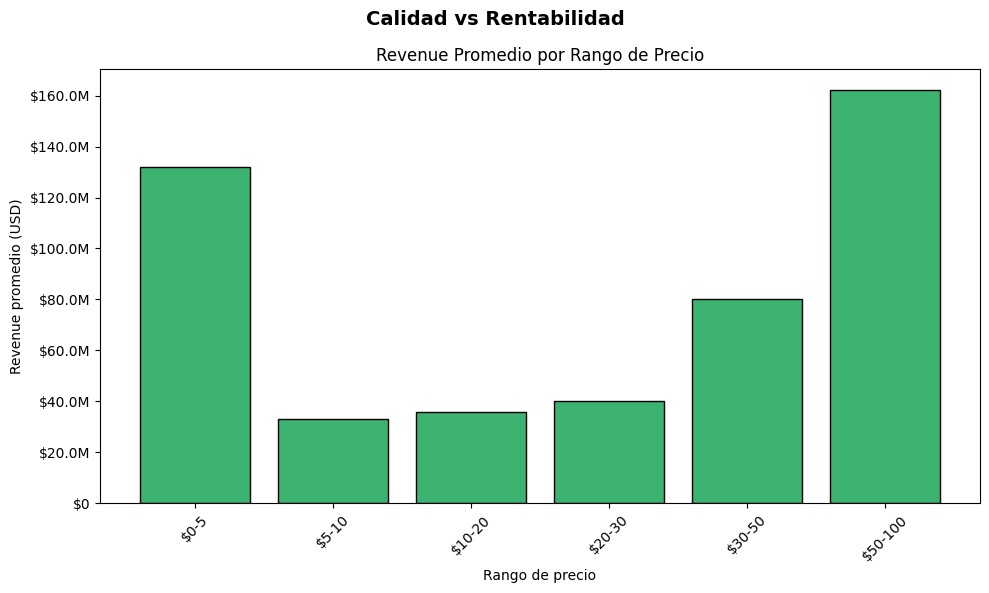

In [ ]:
# ============================================================
# BLOQUE 4 — CALIDAD VS RENTABILIDAD
# ============================================================
# Por qué está acá: una empresa no solo quiere vender mucho,
# quiere saber si vale la pena invertir en calidad. Este bloque
# analiza si los juegos mejor valorados generan más ingresos.
#
# Preguntas que responde:
#   - ¿Los juegos con mejores reviews generan más revenue?
#   - ¿Hay géneros con alta calidad pero bajo revenue (oportunidad)?
#   - ¿Cuál es el "punto dulce" de precio con mejor retorno?

fig, ax = plt.subplots(figsize=(10, 6)) # Cambiado a un solo subgráfico
fig.suptitle('Calidad vs Rentabilidad', fontsize=14, fontweight='bold')

# Gráfico de dispersión: Puntuación de la reseña vs. Ingresos por género
fig_scatter_interactive = px.scatter(
    juegos_con_revenue,
    x='Review_Score_Pct_SteamDB',
    y='Revenue',
    color='Primary_Genre',
    title='Review Score vs Revenue por Género (Interactivo)',
    labels={
        'Review_Score_Pct_SteamDB': 'Review Score (%)',
        'Revenue': 'Revenue (USD)'
    },
    hover_name='Name', # Mostrar el nombre del juego al pasar el ratón
    hover_data={'Primary_Genre': True, 'Price_USD': True, 'Total_Reviews': True} # Datos adicionales al pasar el ratón
)

# Aplicar formato de moneda al eje y (Ingresos)
fig_scatter_interactive.update_yaxes(tickprefix='$', tickformat=",.0f") # Formatear como moneda sin decimales

fig_scatter_interactive.show()

# Revenue promedio por rango de precio
bins = [0, 5, 10, 20, 30, 50, 100, 1000]
labels = ['$0-5', '$5-10', '$10-20', '$20-30', '$30-50', '$50-100', '$100+']
juegos_con_revenue['Rango_Precio'] = pd.cut(juegos_con_revenue['Price_USD'], bins=bins, labels=labels, right=False)
revenue_por_rango = juegos_con_revenue.groupby('Rango_Precio', observed=True)['Revenue'].mean()

ax.bar(revenue_por_rango.index, revenue_por_rango.values, color='mediumseagreen', edgecolor='black')
ax.set_title('Revenue Promedio por Rango de Precio')
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Revenue promedio (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()

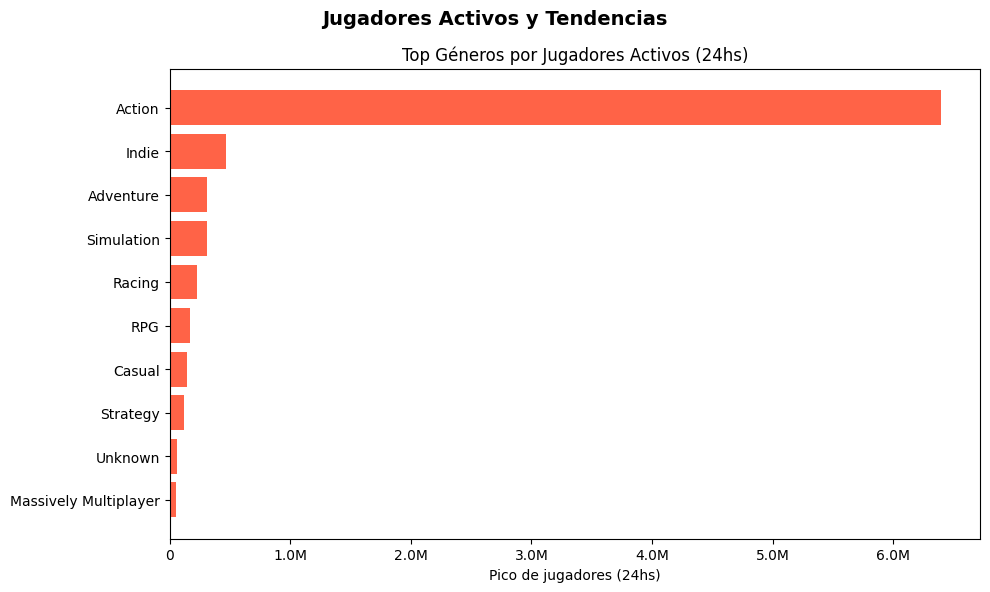

In [ ]:
# ============================================================
# BLOQUE 5 — JUGADORES ACTIVOS Y TENDENCIAS
# ============================================================
# Por qué está acá: el revenue mira el pasado, los jugadores
# activos miran el presente. Este bloque identifica qué géneros
# tienen comunidades vivas hoy, lo cual es clave para una
# empresa que quiere lanzar un juego nuevo.
#
# Pregunta que responde:
#   - ¿Qué géneros tienen más jugadores activos ahora?

fig, ax = plt.subplots(figsize=(10, 6)) # Cambiado a un solo subplot y ajustado el tamaño de la figura
fig.suptitle('Jugadores Activos y Tendencias', fontsize=14, fontweight='bold')

# Top géneros por pico de jugadores activos
jugadores_por_genero = df1.groupby('Primary_Genre')['24h_Peak_Players'].sum().sort_values(ascending=False).head(10)
ax.barh(jugadores_por_genero.index[::-1], jugadores_por_genero.values[::-1], color='tomato')
ax.set_title('Top Géneros por Jugadores Activos (24hs)')
ax.set_xlabel('Pico de jugadores (24hs)')
ax.xaxis.set_major_formatter(FuncFormatter(player_formatter))
# Calcular la distribución de Steam_Deck_Status, incluyendo los valores nulos (desconocidos)
steam_deck_data = juegos_con_revenue['Steam_Deck_Status'].value_counts(dropna=False)
steam_deck_percentages = (steam_deck_data.values / steam_deck_data.sum()) * 100
steam_deck_counts = steam_deck_data.values

df_steam_deck = pd.DataFrame({
    'Original_Status': steam_deck_data.index,
    'Porcentaje': steam_deck_percentages,
    'Count': steam_deck_counts
})

# Reemplazar np.nan en 'Original_Status' con 'Unknown' para las etiquetas del gráfico
df_steam_deck['Steam_Deck_Status_Label'] = df_steam_deck['Original_Status'].fillna('Unknown')

fig = px.pie(df_steam_deck,
             values='Porcentaje',
             names='Steam_Deck_Status_Label', # Usar la nueva columna con etiquetas en inglés (y 'Unknown')
             title='Distribución de juegos por estado de Steam Deck', # Mantener el título en español
             hole=0, # Crea un gráfico de dona
             color_discrete_sequence=px.colors.sequential.RdBu)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label', # Mostrar el porcentaje Y la etiqueta dentro de las rebanadas
    # hovertemplate ahora usará los nombres de 'Steam_Deck_Status_Label' que son en inglés/Unknown
    hovertemplate="<b>%{label}</b><br>Percentage: %{value:.2f}%<br>Number of games: %{customdata:,}<extra></extra>", # Translate hovertemplate
    customdata=df_steam_deck['Count']
)
fig.update_layout(showlegend=True)

plt.tight_layout()
plt.show()
fig.show()

In [ ]:
# ============================================================
# BLOQUE 6 — CONCLUSIONES Y RECOMENDACIONES
# ============================================================
# Por qué está acá: este es el producto final de la consultora.
# No alcanza con mostrar datos, hay que traducirlos en decisiones
# concretas para el cliente.
#
# Preguntas que responde:
#   - ¿En qué género debería invertir una empresa nueva?
#   - ¿A qué precio debería lanzar su juego?

mejor_genero_revenue = revenue_total.index[0]
mejor_genero_jugadores = jugadores_por_genero.index[0]
precio_optimo = revenue_por_rango.idxmax()

print("=" * 55)
print("   RECOMENDACIONES — STEAM GAMES CONSULTORA")
print("=" * 55)

print(f"""
GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      {mejor_genero_revenue}
  → Por jugadores activos:  {mejor_genero_jugadores}

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: {precio_optimo}

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.
""")

   RECOMENDACIONES — STEAM GAMES CONSULTORA

GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      Action
  → Por jugadores activos:  Action

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: $50-100

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.



=== DISPONIBILIDAD POR SISTEMA OPERATIVO (Merge datasets) ===
Windows   : 264 juegos (100.0%)
Mac       : 62 juegos (23.5%)
Linux     : 42 juegos (15.9%)


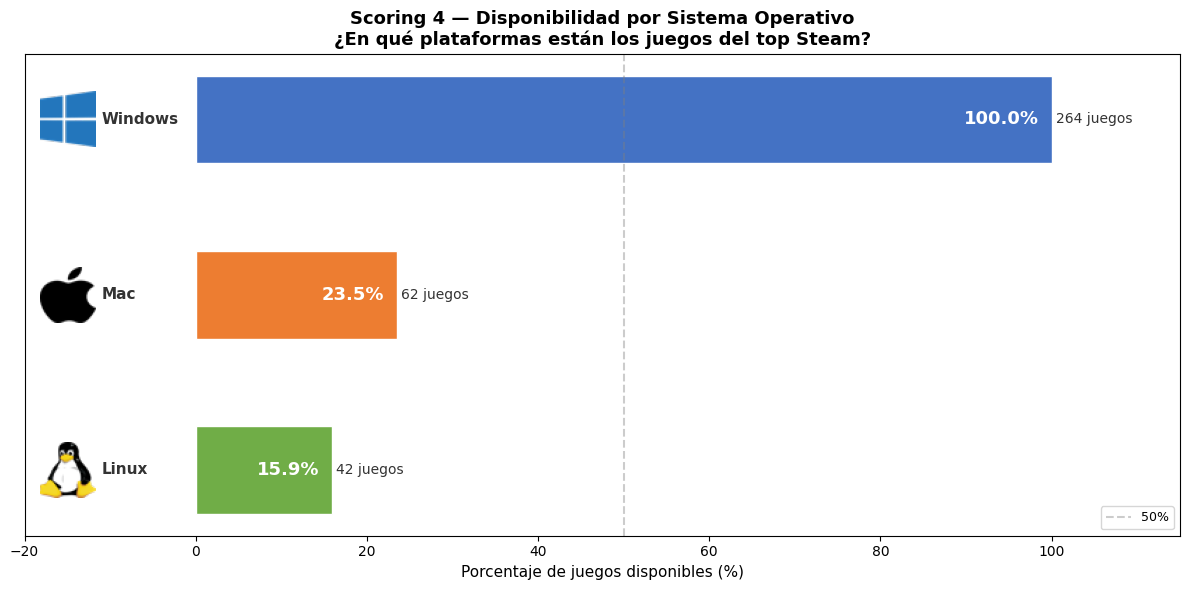

In [ ]:
# ============================================================
# SCORING 4a — DISPONIBILIDAD POR SISTEMA OPERATIVO
# ============================================================

# Asegurar que 'AppID' y 'app_id' sean numéricos para la fusión
juegos_con_revenue['AppID'] = pd.to_numeric(juegos_con_revenue['AppID'], errors='coerce')
df2['app_id'] = pd.to_numeric(df2['app_id'], errors='coerce')

# Fusionar 'juegos_con_revenue' con 'df2' para obtener información de la plataforma para estos juegos
# Seleccionar solo las columnas de plataforma necesarias de 'df2'
platform_cols = ['app_id', 'win', 'mac', 'linux', 'steam_deck']
juegos_con_revenue_platforms = pd.merge(
    juegos_con_revenue,
    df2[platform_cols],
    left_on='AppID',
    right_on='app_id',
    how='left'
)

# Eliminar la columna 'app_id' redundante si existe después de la fusión
if 'app_id' in juegos_con_revenue_platforms.columns:
    juegos_con_revenue_platforms = juegos_con_revenue_platforms.drop(columns=['app_id'])

# Calcular el número de juegos para los cuales los datos de la plataforma se fusionaron con éxito
num_matched_games = juegos_con_revenue_platforms['win'].notna().sum()

# Actualizar el total para el cálculo del porcentaje para reflejar solo los juegos fusionados con éxito
total_games_analyzed = num_matched_games

# Solo sistemas operativos de PC (Steam Deck excluido de este recuento específico según el comentario original)
plataformas = {
    'Windows': int(juegos_con_revenue_platforms['win'].sum()),
    'Mac':     int(juegos_con_revenue_platforms['mac'].sum()),
    'Linux':   int(juegos_con_revenue_platforms['linux'].sum())
}

# Rutas a los logos subidos localmente
logo_paths = {
    'Windows': "windows-10-icon-seeklogo.png",
    'Mac': "apple-seeklogo.png",
    'Linux': "linux-tux-seeklogo.png"
}

# Cargar imágenes de logos desde archivos locales
logos = {}
logo_size_pixels = 40
for os_name, path in logo_paths.items():
    try:
        # Abrir y convertir a RGBA para asegurar un manejo consistente del color y la transparencia
        logos[os_name] = Image.open(path).convert("RGBA").resize((logo_size_pixels, logo_size_pixels)) # Redimensionar para el gráfico
    except Exception as e:
        print(f"Error al cargar el logo de {os_name} desde {path}: {e}")
        logos[os_name] = None # Si hay error, no se usará logo

# Etiquetas sin emojis, usaremos las imágenes
labels = list(plataformas.keys()) # E.g., ['Windows', 'Mac', 'Linux']
valores  = list(plataformas.values())
porcentajes = [v / total_games_analyzed * 100 for v in valores]
colores  = ['#4472C4', '#ED7D31', '#70AD47']

print("=== DISPONIBILIDAD POR SISTEMA OPERATIVO (Merge datasets) ===")
for plat, cantidad, pct in zip(labels, valores, porcentajes):
    print(f"{plat:10}: {cantidad:,} juegos ({pct:.1f}%)")

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(12, 6)) # Aumentar el tamaño para los logos

# Invertir el orden para que Windows esté arriba y Linux abajo en el gráfico
labels_plot_reversed = labels[::-1] # E.g., ['Linux', 'Mac', 'Windows']
porcentajes_reversed = porcentajes[::-1]
valores_reversed = valores[::-1]
colores_reversed = colores[::-1]

bars = ax.barh(labels_plot_reversed, porcentajes_reversed,
               color=colores_reversed, edgecolor='white', height=0.5)

# Ocultar las etiquetas por defecto del eje Y, las crearemos manualmente
ax.set_yticklabels([])
ax.tick_params(axis='y', length=0) # También ocultar los ticks del eje Y

# Etiqueta con porcentaje Y cantidad exacta dentro/fuera de cada barra
for i, (bar, pct, cant) in enumerate(zip(bars, porcentajes_reversed, valores_reversed)):
    # Texto dentro de la barra (porcentaje)
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', ha='right',
            fontsize=13, fontweight='bold', color='white')
    # Texto fuera de la barra (conteo de juegos)
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{cant:,} juegos', va='center', ha='left',
            fontsize=10, color='#333333')

    # Colocar logo y nombre del SO en el eje Y
    current_os_name = labels_plot_reversed[i] # E.g., 'Linux', 'Mac', 'Windows'
    logo_to_use = logos.get(current_os_name)

    if logo_to_use:
        imagebox = OffsetImage(logo_to_use, zoom=1.0)
        imagebox.image.axes = ax

        # Definir la posición x para el centro del logo en coordenadas de datos
        x_logo_data_center = -15 # Posición x ajustada para centrar y más espacio

        ab = AnnotationBbox(imagebox, (x_logo_data_center, bar.get_y() + bar.get_height() / 2),
                            xybox=(0, 0), # Sin desplazamiento adicional en puntos
                            xycoords='data',
                            boxcoords="offset points", # Desplazamiento desde xy en puntos
                            box_alignment=(0.5, 0.5), # Centrar el imagebox en xy
                            bboxprops=dict(edgecolor='none'),
                            frameon=False,
                            pad=0.0 # Eliminar relleno alrededor de la imagen
                           )
        ax.add_artist(ab)

        # Colocar el texto del nombre del SO
        x_text_data_start = -11 # Posición x ajustada a la derecha del logo y más espacio

        ax.text(x_text_data_start, bar.get_y() + bar.get_height() / 2,
                current_os_name, va='center', ha='left',
                fontsize=11, fontweight='bold', color='#333333')

# Ajustar los límites del eje X para dejar espacio para los logos y las etiquetas
ax.set_xlim(-20, 115) # Expandir a la izquierda para acomodar logos y texto (ajustado de -18)
ax.set_xlabel('Porcentaje de juegos disponibles (%)', fontsize=11)
ax.set_ylabel('') # Sin etiqueta del eje Y por defecto
ax.set_title('Scoring 4 — Disponibilidad por Sistema Operativo\n'
             '¿En qué plataformas están los juegos del top Steam?',
             fontsize=13, fontweight='bold')

# Línea de referencia al 50%
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.4, label='50%')
ax.legend(fontsize=9, loc='lower right') # Posicionar la leyenda para evitar superposiciones

plt.tight_layout()
plt.savefig('scoring4_so.png', dpi=150, bbox_inches='tight')
plt.show()

=== DISPONIBILIDAD POR SISTEMA OPERATIVO (Todos los juegos) ===
Windows   : 50,076 juegos (98.4%)
Mac       : 13,018 juegos (25.6%)
Linux     : 9,041 juegos (17.8%)


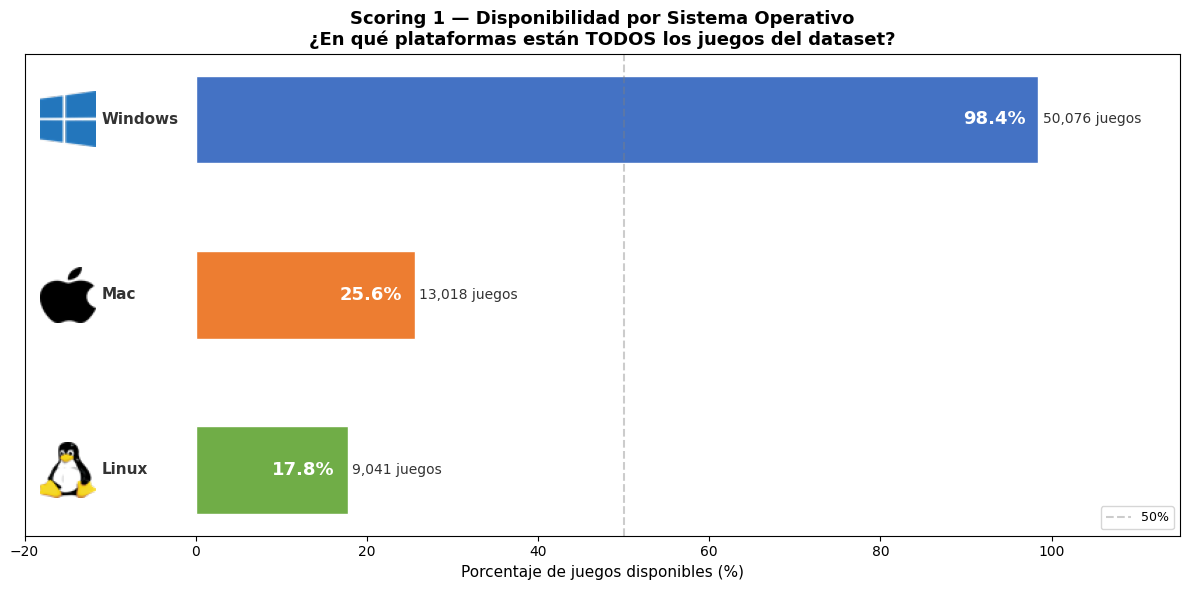

In [ ]:
# ============================================================
# SCORING 4b — DISPONIBILIDAD POR SISTEMA OPERATIVO (Todos los juegos de games_dataset)
# ============================================================

# Asegurar que 'app_id' sea numérico en df2 (ya se hace en Bloque 0, pero por si acaso)
df2_platform_analysis = df2.copy()
df2_platform_analysis['app_id'] = pd.to_numeric(df2_platform_analysis['app_id'], errors='coerce')

# Eliminar filas con app_id nulos si los hubiera tras la conversión
df2_platform_analysis.dropna(subset=['app_id'], inplace=True)

# El total de juegos a analizar es ahora el tamaño de df2_platform_analysis
total_games_analyzed_full = len(df2_platform_analysis)

# Contar la disponibilidad por sistema operativo usando df2_platform_analysis
plataformas_full = {
    'Windows': int(df2_platform_analysis['win'].sum()),
    'Mac':     int(df2_platform_analysis['mac'].sum()),
    'Linux':   int(df2_platform_analysis['linux'].sum())
}

# Rutas a los logos subidos localmente (reutilizamos las rutas)
# Estos logos ya se cargaron en la celda anterior o en el BLOQUE 0

# Etiquetas y valores
labels_full  = list(plataformas_full.keys())
valores_full  = list(plataformas_full.values())
porcentajes_full = [v / total_games_analyzed_full * 100 for v in valores_full]
colores_full  = ['#4472C4', '#ED7D31', '#70AD47']

print("=== DISPONIBILIDAD POR SISTEMA OPERATIVO (Todos los juegos) ===")
for plat, cantidad, pct in zip(labels_full, valores_full, porcentajes_full):
    print(f"{plat:10}: {cantidad:,} juegos ({pct:.1f}%)")

# Gráfico de barras horizontales
fig_full, ax_full = plt.subplots(figsize=(12, 6))

# Invertir el orden para que Windows esté arriba y Linux abajo en el gráfico
labels_plot_reversed_full = labels_full[::-1]
porcentajes_reversed_full = porcentajes_full[::-1]
valores_reversed_full = valores_full[::-1]
colores_reversed_full = colores_full[::-1]

bars_full = ax_full.barh(labels_plot_reversed_full, porcentajes_reversed_full,
               color=colores_reversed_full, edgecolor='white', height=0.5)

# Ocultar las etiquetas por defecto del eje Y, las crearemos manualmente
ax_full.set_yticklabels([])
ax_full.tick_params(axis='y', length=0) # También ocultar los ticks del eje Y

# Etiqueta con porcentaje Y cantidad exacta dentro/fuera de cada barra
for i, (bar, pct, cant) in enumerate(zip(bars_full, porcentajes_reversed_full, valores_reversed_full)):
    # Texto dentro de la barra (porcentaje)
    ax_full.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', ha='right',
            fontsize=13, fontweight='bold', color='white')
    # Texto fuera de la barra (conteo de juegos)
    ax_full.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{cant:,} juegos', va='center', ha='left',
            fontsize=10, color='#333333')

    # Colocar logo y nombre del SO en el eje Y
    current_os_name_full = labels_plot_reversed_full[i]
    logo_to_use_full = logos.get(current_os_name_full) # Reutilizamos 'logos' cargado previamente

    if logo_to_use_full:
        imagebox_full = OffsetImage(logo_to_use_full, zoom=1.0)
        imagebox_full.image.axes = ax_full

        x_logo_data_center_full = -15

        ab_full = AnnotationBbox(imagebox_full, (x_logo_data_center_full, bar.get_y() + bar.get_height() / 2),
                            xybox=(0, 0),
                            xycoords='data',
                            boxcoords="offset points",
                            box_alignment=(0.5, 0.5),
                            bboxprops=dict(edgecolor='none'),
                            frameon=False,
                            pad=0.0
                           )
        ax_full.add_artist(ab_full)

        x_text_data_start_full = -11

        ax_full.text(x_text_data_start_full, bar.get_y() + bar.get_height() / 2,
                current_os_name_full, va='center', ha='left',
                fontsize=11, fontweight='bold', color='#333333')

# Ajustar límites del eje X
ax_full.set_xlim(-20, 115)
ax_full.set_xlabel('Porcentaje de juegos disponibles (%)', fontsize=11)
ax_full.set_ylabel('')
ax_full.set_title('Scoring 1 — Disponibilidad por Sistema Operativo\n'
             '¿En qué plataformas están TODOS los juegos del dataset?',
             fontsize=13, fontweight='bold')

# Línea de referencia al 50%
ax_full.axvline(x=50, color='gray', linestyle='--', alpha=0.4, label='50%')
ax_full.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('scoring4_so_full_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

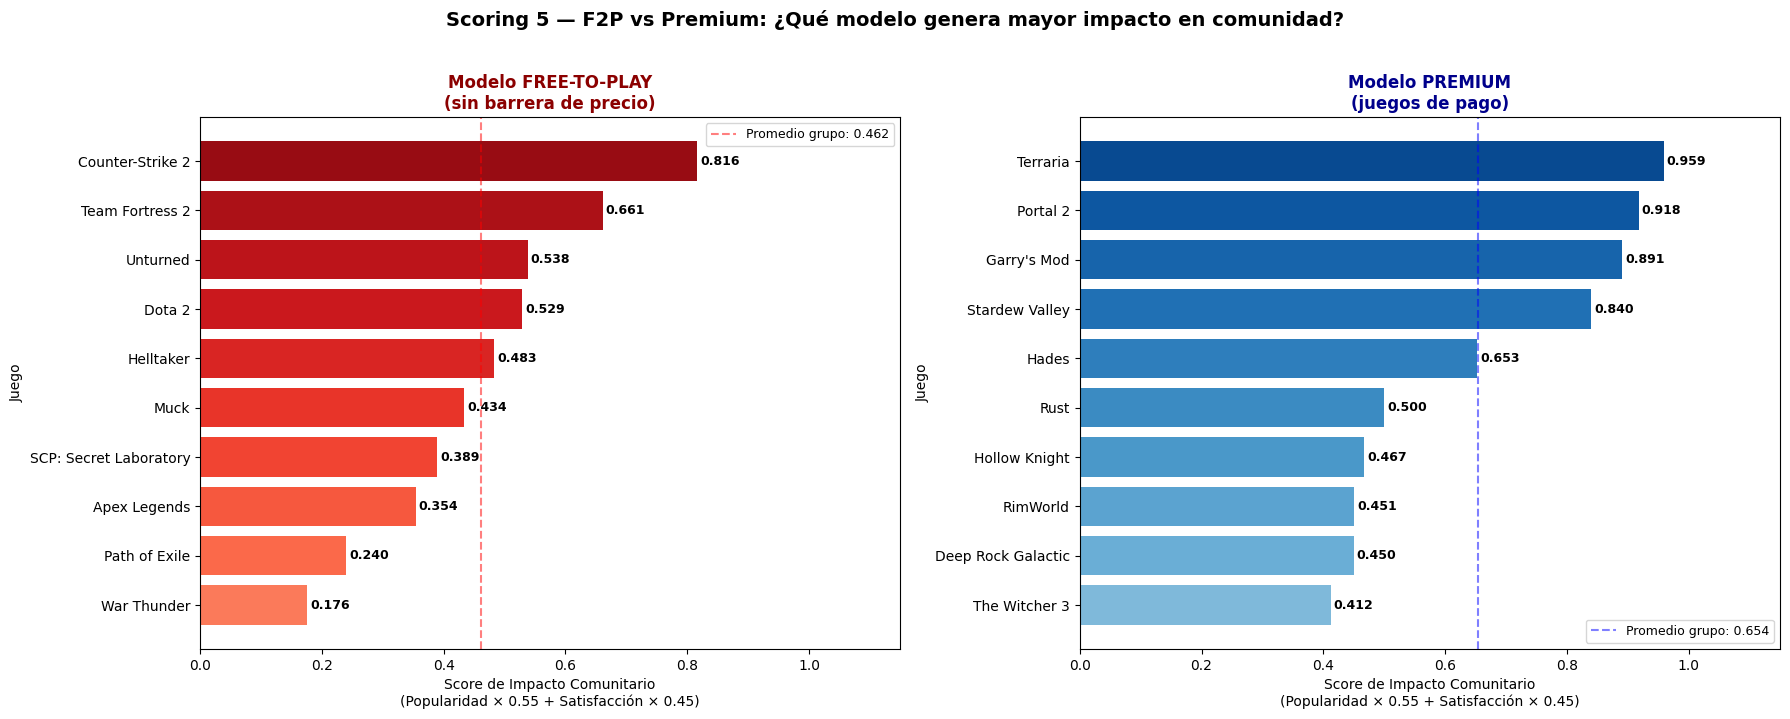


CONCLUSIÓN — SCORING 5: F2P vs PREMIUM
Score promedio F2P:     0.462
Score promedio Premium: 0.654
Modelo con mayor impacto comunitario: PREMIUM
Diferencia entre modelos: 0.192


In [ ]:
# ============================================================
# SCORING 5A y 5B — F2P vs PREMIUM: Comparativa de Impacto
# ============================================================

data_f2p = {
    'title':          ['Counter-Strike 2', 'Dota 2', 'Team Fortress 2',
                       'Apex Legends', 'War Thunder', 'Path of Exile',
                       'Unturned', 'Helltaker', 'SCP: Secret Laboratory', 'Muck'],
    'user_reviews':   [7494460, 2045628, 985819, 713182, 393681,
                       152000, 515016, 127378, 98000, 139841],
    'positive_ratio': [88, 82, 93, 80, 75, 84, 91, 97, 94, 94],
}

data_premium = {
    'title':          ['Terraria', "Garry's Mod", 'Rust', 'Stardew Valley',
                       'Hollow Knight', 'Portal 2', 'RimWorld', 'Hades',
                       'Deep Rock Galactic', 'The Witcher 3'],
    'user_reviews':   [943413, 853733, 786668, 612000, 158000,
                       701000, 173000, 310000, 128000, 202000],
    'positive_ratio': [97, 96, 87, 97, 97, 98, 96, 97, 98, 94],
}

def calcular_scoring(df):
    scaler = MinMaxScaler()
    df = df.copy()
    df['log_reviews']   = np.log1p(df['user_reviews'])
    df['log_reviews_n'] = scaler.fit_transform(df[['log_reviews']])
    df['positive_n']    = scaler.fit_transform(df[['positive_ratio']])
    df['score'] = (
        df['log_reviews_n'] * 0.55 +
        df['positive_n']    * 0.45
    ).round(3)
    return df.sort_values('score', ascending=False)

df_f2p_scored     = calcular_scoring(pd.DataFrame(data_f2p))
df_premium_scored = calcular_scoring(pd.DataFrame(data_premium))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Scoring 5 — F2P vs Premium: ¿Qué modelo genera mayor impacto en comunidad?',
             fontsize=14, fontweight='bold', y=1.02)

# ── GRÁFICO A — F2P ──────────────────────────────────────
colores_f2p = plt.cm.Reds(np.linspace(0.45, 0.9, 10))
bars1 = ax1.barh(df_f2p_scored['title'][::-1],
                 df_f2p_scored['score'][::-1], color=colores_f2p)

# Solo el score encima de cada barra, sin el número de reviews
for bar, val in zip(bars1, df_f2p_scored['score'][::-1]):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax1.set_xlim(0, 1.15)
ax1.set_xlabel('Score de Impacto Comunitario\n(Popularidad × 0.55 + Satisfacción × 0.45)',
               fontsize=10)
ax1.set_ylabel('Juego', fontsize=10)
ax1.set_title('Modelo FREE-TO-PLAY\n(sin barrera de precio)',
              fontsize=12, fontweight='bold', color='darkred')
ax1.axvline(x=df_f2p_scored['score'].mean(), color='red',
            linestyle='--', alpha=0.5,
            label=f'Promedio grupo: {df_f2p_scored["score"].mean():.3f}')
ax1.legend(fontsize=9)

# ── GRÁFICO B — PREMIUM ──────────────────────────────────
colores_prem = plt.cm.Blues(np.linspace(0.45, 0.9, 10))
bars2 = ax2.barh(df_premium_scored['title'][::-1],
                 df_premium_scored['score'][::-1], color=colores_prem)

for bar, val in zip(bars2, df_premium_scored['score'][::-1]):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax2.set_xlim(0, 1.15)
ax2.set_xlabel('Score de Impacto Comunitario\n(Popularidad × 0.55 + Satisfacción × 0.45)',
               fontsize=10)
ax2.set_ylabel('Juego', fontsize=10)
ax2.set_title('Modelo PREMIUM\n(juegos de pago)',
              fontsize=12, fontweight='bold', color='darkblue')
ax2.axvline(x=df_premium_scored['score'].mean(), color='blue',
            linestyle='--', alpha=0.5,
            label=f'Promedio grupo: {df_premium_scored["score"].mean():.3f}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('scoring5_f2p_vs_premium.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CONCLUSIÓN AUTOMÁTICA ─────────────────────────────────
prom_f2p  = df_f2p_scored['score'].mean()
prom_prem = df_premium_scored['score'].mean()
ganador   = "FREE-TO-PLAY" if prom_f2p > prom_prem else "PREMIUM"
diferencia = abs(prom_f2p - prom_prem)

print("\n" + "="*55)
print("CONCLUSIÓN — SCORING 5: F2P vs PREMIUM")
print("="*55)
print(f"Score promedio F2P:     {prom_f2p:.3f}")
print(f"Score promedio Premium: {prom_prem:.3f}")
print(f"Modelo con mayor impacto comunitario: {ganador}")
print(f"Diferencia entre modelos: {diferencia:.3f}")

Juegos en el merge: 264

Comparación de fuentes de calidad:
                                  Name  Review_Score_Pct_SteamDB  positive_ratio                   rating
0                     Counter-Strike 2                     85.87              88            Very Positive
1                         Ready or Not                     77.27              91            Very Positive
2                        Apex Legends™                     67.38              80            Very Positive
3                             Teardown                     94.51              96  Overwhelmingly Positive
4                          The Sims™ 4                     85.61              87            Very Positive
5       Tom Clancy's Rainbow Six Siege                     82.00              86            Very Positive
6                             Warframe                     86.70              86            Very Positive
7                           Overwatch®                     30.36               9  Overwhelmi

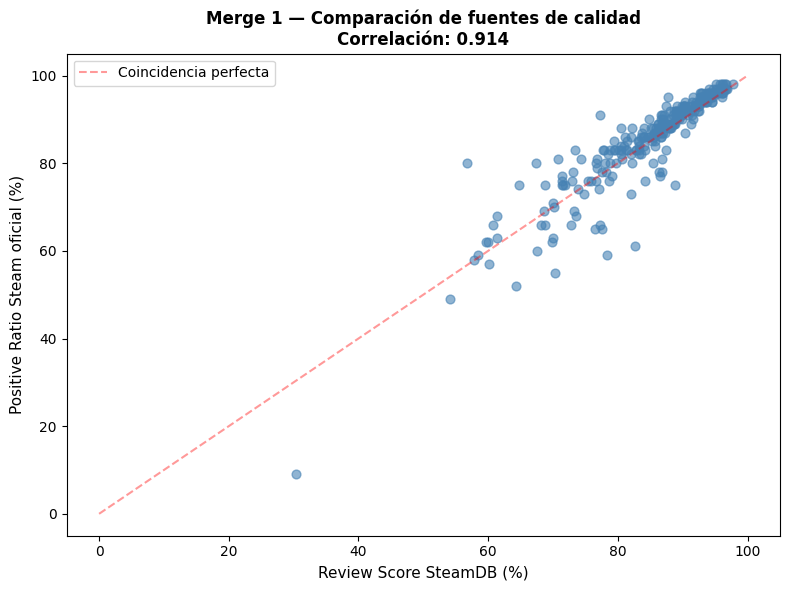

In [ ]:
# ============================================================
# MERGE 1 — ENRIQUECIMIENTO DE CALIDAD
# Unir Review_Score_Pct_SteamDB con positive_ratio oficial de Steam
# ============================================================

df1['AppID']   = pd.to_numeric(df1['AppID'], errors='coerce')
df2['app_id']  = pd.to_numeric(df2['app_id'], errors='coerce')
df2['positive_ratio'] = pd.to_numeric(df2['positive_ratio'], errors='coerce')

# Merge por AppID — inner: solo juegos presentes en ambos
merge1 = pd.merge(
    df1[['AppID', 'Name', 'Primary_Genre', 'Review_Score_Pct_SteamDB',
         'Revenue' if 'Revenue' in df1.columns else 'Estimated_Owners']],
    df2[['app_id', 'positive_ratio', 'rating']],
    left_on='AppID', right_on='app_id',
    how='inner'
)

print(f"Juegos en el merge: {len(merge1)}")
print(f"\nComparación de fuentes de calidad:")
print(merge1[['Name', 'Review_Score_Pct_SteamDB', 'positive_ratio', 'rating']].head(10).to_string())

# Correlación entre las dos fuentes
correlacion = merge1['Review_Score_Pct_SteamDB'].corr(merge1['positive_ratio'])
print(f"\nCorrelación entre SteamDB score y positive_ratio: {correlacion:.3f}")

# Scatter para ver la relación
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merge1['Review_Score_Pct_SteamDB'], merge1['positive_ratio'],
           alpha=0.6, color='steelblue', s=40)
ax.set_xlabel('Review Score SteamDB (%)', fontsize=11)
ax.set_ylabel('Positive Ratio Steam oficial (%)', fontsize=11)
ax.set_title('Merge 1 — Comparación de fuentes de calidad\n'
             f'Correlación: {correlacion:.3f}', fontsize=12, fontweight='bold')

# Línea de referencia perfecta (si coincidieran 100%)
ax.plot([0, 100], [0, 100], 'r--', alpha=0.4, label='Coincidencia perfecta')
ax.legend()
plt.tight_layout()
plt.show()

TOP 10 — KPI N°2: Revenue por Owner (RPO)
                        Name Primary_Genre  Price_USD      Revenue  Estimated_Owners  user_reviews   RPO
               Battlefield 6        Action      69.99 3.984954e+08          10220730           NaN 38.99
        Monster Hunter Wilds        Action      69.99 3.723531e+08           9553740           NaN 38.97
       Resident Evil Requiem        Action      69.99 1.979937e+08           5105160           NaN 38.78
              Crimson Desert        Action      69.99 1.764430e+08           4555320           NaN 38.73
         Need for Speed Heat        Action      69.99 1.726886e+08           4459530       69978.0 38.72
    STAR WARS Jedi: Survivor        Action      69.99 9.472977e+07           2470500       33280.0 38.34
               Borderlands 4        Action      69.99 9.078485e+07           2369850           NaN 38.31
 DRAGON BALL: Sparking! ZERO        Action      69.99 8.076206e+07           2114130           NaN 38.20
      Need fo

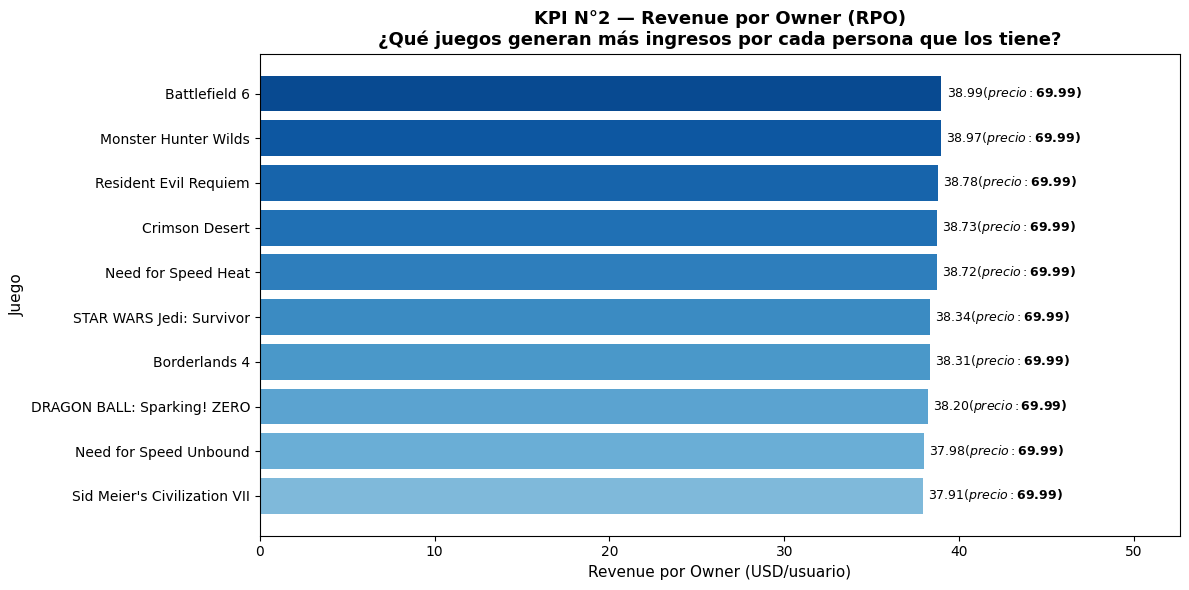


RPO promedio del mercado: $16.74
RPO mediano:              $14.97


In [ ]:
# ============================================================
# KPI N°2 — RPO (Revenue por Owner)
# Fórmula: Revenue / Estimated_Owners
# Mide: eficiencia económica por usuario
# Merge aporta: user_reviews de df2 para enriquecer el análisis
# ============================================================

df = juegos_con_revenue.copy()

# Asegurarse de que AppID y app_id son numéricos para el merge (aunque probablemente ya se hizo en celdas anteriores)
df['AppID'] = pd.to_numeric(df['AppID'], errors='coerce')
df2['app_id'] = pd.to_numeric(df2['app_id'], errors='coerce')

# Fusionar con df2 para obtener la columna 'user_reviews' para 'df'
df = pd.merge(
    df,
    df2[['app_id', 'user_reviews']],
    left_on='AppID',
    right_on='app_id',
    how='left'
)

# Eliminar la columna 'app_id' redundante de df
if 'app_id' in df.columns:
    df = df.drop(columns=['app_id'])

df['RPO'] = (df['Revenue'] / df['Estimated_Owners']).round(2)

# Enriquecimiento con df2: añadimos user_reviews como contexto
# Un RPO alto con muchas user_reviews es más sólido que uno con pocas
df['RPO_confianza'] = np.log1p(df['user_reviews'])  # peso de confianza

top_rpo = df[['Name','Primary_Genre','Price_USD','Revenue',
              'Estimated_Owners','user_reviews','RPO']].sort_values('RPO', ascending=False).head(10)

# Limpiar nombres para evitar problemas de visualización con caracteres especiales
# Eliminando explícitamente el símbolo de marca registrada Unicode U+2122 y la variante común \x99
top_rpo['Name'] = top_rpo['Name'].str.replace('™', '', regex=False).str.replace('\x99', '', regex=False)

print("TOP 10 — KPI N°2: Revenue por Owner (RPO)")
print(top_rpo.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.Blues(np.linspace(0.45, 0.9, 10))
bars = ax.barh(top_rpo['Name'][::-1], top_rpo['RPO'][::-1], color=colores)

for bar, val, precio in zip(bars, top_rpo['RPO'][::-1], top_rpo['Price_USD'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}  (precio: ${precio:.2f})',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, top_rpo['RPO'].max() * 1.35)
ax.set_xlabel('Revenue por Owner (USD/usuario)', fontsize=11)
ax.set_ylabel('Juego', fontsize=11)
ax.set_title('KPI N°2 — Revenue por Owner (RPO)\n'
             '¿Qué juegos generan más ingresos por cada persona que los tiene?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRPO promedio del mercado: ${df['RPO'].mean():.2f}")
print(f"RPO mediano:              ${df['RPO'].median():.2f}")

In [ ]:
# ============================================================
# KPI N°6 — TASA DE TRACCIÓN TEMPRANA (TTT)
# VERSIÓN PROFESIONAL INTERACTIVA
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# ============================================================
# PREPARACIÓN DE DATOS PARA KPI N°6
# ============================================================

df_kpi6 = juegos_con_revenue.copy()

# Drop existing 'user_reviews' and 'positive_ratio' from df_kpi6 if they exist,
# to ensure we always use the versions from df2 and avoid potential conflicts
# or stale data from juegos_con_revenue.
if 'user_reviews' in df_kpi6.columns:
    df_kpi6 = df_kpi6.drop(columns=['user_reviews'])
if 'positive_ratio' in df_kpi6.columns:
    df_kpi6 = df_kpi6.drop(columns=['positive_ratio'])

# Asegurarse de que AppID y app_id son numéricos para el merge
df_kpi6['AppID'] = pd.to_numeric(df_kpi6['AppID'], errors='coerce')
df2['app_id'] = pd.to_numeric(df2['app_id'], errors='coerce')

# Fusionar con df2 para obtener las columnas 'user_reviews' y 'positive_ratio'
# Esta operación es ahora incondicional para garantizar la presencia de las columnas.
df_kpi6 = pd.merge(
    df_kpi6,
    df2[['app_id', 'user_reviews', 'positive_ratio']],
    left_on='AppID',
    right_on='app_id',
    how='left'
)
# Eliminar la columna 'app_id' redundante
if 'app_id' in df_kpi6.columns:
    df_kpi6 = df_kpi6.drop(columns=['app_id'])

# ============================================================
# KPI
# ============================================================

# Convert Release_Date to datetime, handling potential mixed formats or errors
df_kpi6['Release_Date'] = pd.to_datetime(df_kpi6['Release_Date'], errors='coerce', dayfirst=True)

# Calculate 'años_en_mercado'
# Use 2024 as the reference year for calculation, consistent with other forecast cells
current_year_for_age_calculation = 2024

df_kpi6['años_en_mercado'] = current_year_for_age_calculation - df_kpi6['Release_Date'].dt.year

# Handle cases where 'años_en_mercado' might be 0 or negative (for future releases)
# A game should at least have been on the market for 1 year for this KPI to make sense
df_kpi6['años_en_mercado'] = df_kpi6['años_en_mercado'].apply(lambda x: max(1, x))

# Ensure 'user_reviews' is numeric and fill NaN with 0 before division
df_kpi6['user_reviews'] = pd.to_numeric(df_kpi6['user_reviews'], errors='coerce').fillna(0)

df_kpi6['TTT'] = (
    df_kpi6['user_reviews'] /
    df_kpi6['años_en_mercado']
).round(2)

# ============================================================
# TOP 10
# ============================================================

top_ttt = (
    df_kpi6[['Name',
        'Primary_Genre',
        'años_en_mercado',
        'user_reviews',
        'positive_ratio',
        'TTT']]
    .sort_values('TTT', ascending=False)
    .head(10)
)

# ============================================================
# ESCALA LOGARÍTMICA
# ============================================================

top_ttt['TTT_LOG'] = np.log1p(top_ttt['TTT'])

datos = top_ttt.sort_values(
    'TTT_LOG',
    ascending=True
)

# ============================================================
# PALETA DE COLORES (ORIGINAL)
# ============================================================

colores = px.colors.sample_colorscale(
    "Oranges",
    np.linspace(0.45, 0.95, len(datos))
)

# ============================================================
# GRÁFICO
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=datos['TTT_LOG'],
        y=datos['Name'],

        orientation='h',

        marker=dict(
            color=colores,
            line=dict(
                width=0
            )
        ),

        customdata=np.stack([
            datos['TTT'],
            datos['años_en_mercado'],
            datos['user_reviews'],
            datos['positive_ratio'],
            datos['Primary_Genre']
        ], axis=-1),

        hovertemplate=
        "<b>%{y}</b><br><br>" +
        "TTT: %{customdata[0]:,.0f} reviews/año<br>" +
        "Años en mercado: %{customdata[1]:.1f}<br>" +
        "Reviews totales: %{customdata[2]:,.0f}<br>" +
        "Reviews positivas: %{customdata[3]:.0f}%<br>" +
        "Género: %{customdata[4]}<br>" +
        "<extra></extra>"
    )
)

# ============================================================
# DROPDOWN
# ============================================================

fig.update_layout(

    updatemenus=[
        dict(
            buttons=[

                dict(
                    label="Top 10",
                    method="restyle",
                    args=[{
                        "x": [datos['TTT_LOG']],
                        "y": [datos['Name']]
                    }]
                ),

                dict(
                    label="Top 5",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(5)['TTT_LOG']],
                        "y": [datos.tail(5)['Name']]
                    }]
                ),

                dict(
                    label="Top 3",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(3)['TTT_LOG']],
                        "y": [datos.tail(3)['Name']]
                    }]
                )

            ],

            direction="down",

            x=1.02,
            y=1.15,

            showactive=True
        )
    ],

    title=dict(
        text=
        "<b>KPI N°6 — Tasa de Tracción Temprana (TTT)</b><br>" +
        "¿Qué juegos generaron comunidad más rápido tras su lanzamiento?",
        x=0.5
    ),

    template="plotly_white",

    height=750,

    showlegend=False,

    xaxis_title="Tasa de Tracción (escala log — reviews por año)",

    yaxis_title="",

    margin=dict(
        l=60,
        r=80,
        t=100,
        b=50
    ),

    dragmode=False
)

# ============================================================
# BLOQUEAR ZOOM Y MOVIMIENTO
# ============================================================

fig.update_xaxes(
    fixedrange=True,
    showgrid=True
)

fig.update_yaxes(
    fixedrange=True
)

# ============================================================
# MOSTRAR
# ============================================================

fig.show(
    config={
        "displayModeBar": False,
        "scrollZoom": False,
        "doubleClick": False,
        "responsive": True
    }
)

In [ ]:
# ============================================================
# KPI N°9 — RRG INTERACTIVO (ESTILO ORIGINAL)
# ============================================================

# Asegurar que AppID y app_id sean numéricos para la fusión
juegos_con_revenue['AppID'] = pd.to_numeric(juegos_con_revenue['AppID'], errors='coerce')
df2['app_id'] = pd.to_numeric(df2['app_id'], errors='coerce')

# Remove redundant positive_ratio merge as it's now calculated directly from df1
# The calculated 'positive_ratio' is now available in 'juegos_con_revenue' from df1 processing.
# This block no longer needs to merge it from df2.

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

revenue_promedio_genero = (
    juegos_con_revenue.groupby('Primary_Genre')['Revenue']
      .transform('mean')
)

juegos_con_revenue['RRG'] = (
    juegos_con_revenue['Revenue'] / revenue_promedio_genero
).round(3)

top_rrg = (
    juegos_con_revenue[['Name','Primary_Genre','Revenue','RRG','positive_ratio']]
    .sort_values('RRG', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# ORDEN IGUAL AL GRÁFICO ORIGINAL
# ------------------------------------------------------------

plot_df = top_rrg.iloc[::-1].copy()

# ------------------------------------------------------------
# COLORES IGUALES AL MATPLOTLIB
# ------------------------------------------------------------

cmap = px.colors.sample_colorscale(
    "RdYlGn",
    np.linspace(0.30, 0.90, len(plot_df))
)

# ------------------------------------------------------------
# BARRAS
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_df["RRG"],
        y=plot_df["Name"],

        orientation="h",

        marker=dict(
            color=cmap[::-1]
        ),

        text=[
            f"{rrg:.2f}x [{gen}]"
            for rrg, gen in zip(
                plot_df["RRG"],
                plot_df["Primary_Genre"]
            )
        ],

        textposition="outside",

        hovertemplate=
        "<b>%{y}</b><br>" +
        "RRG: %{x:.2f}x<br>" +
        "Género: %{customdata[0]}<br>" +
        "Revenue: $%{customdata[1]:,.0f}<br>" +
        "Positive Ratio: %{customdata[2]:.1f}%<br>" +
        "<extra></extra>",

        customdata=np.stack(
            [
                plot_df["Primary_Genre"],
                plot_df["Revenue"],
                plot_df["positive_ratio"]
            ],
            axis=-1
        )
    )
)

# ------------------------------------------------------------
# LINEA RRG = 1
# ------------------------------------------------------------

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="black",
    line_width=3
)

# ------------------------------------------------------------
# ESTILO
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "<b>KPI N°9 — Rentabilidad Relativa al Género (RRG)</b>"
            "<br>"
            "Compara juegos de distintos géneros en igualdad de condiciones"
        ),
        x=0.5
    ),

    xaxis_title="Múltiplo sobre el promedio del género",

    yaxis_title="Juego",

    template="plotly_white",

    height=750,

    showlegend=False,

    margin=dict(
        l=50,
        r=120,
        t=90,
        b=50
    )
)

fig.update_xaxes(
    range=[0, top_rrg["RRG"].max()*1.3]
)

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config=
        {
            "displayModeBar": True,
            "scrollZoom": False,
            "doubleClick": "reset"
        }
)

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ============================================================
# PREPARACIÓN DE DATOS PARA KPI N°10
# ============================================================

# Use the larger df2 (games_dataset) for a more robust ILC analysis as requested by the user
df_kpi10 = df2.copy()

# Rename columns to match the general structure used previously for ILC calculation
df_kpi10 = df_kpi10.rename(columns={
    'app_id': 'AppID',
    'title': 'Name',
    'date_release': 'Release_Date',
    'user_reviews': 'Player_Count_Proxy' # Using user_reviews as a proxy for player activity/longevity
})

# Convert Release_Date to datetime. df2's 'date_release' is typically YYYY-MM-DD.
df_kpi10['Release_Date'] = pd.to_datetime(df_kpi10['Release_Date'], errors='coerce', dayfirst=False)

# Remove rows where Release_Date could not be parsed
df_kpi10.dropna(subset=['Release_Date'], inplace=True)

# Calculate 'años_en_mercado' more precisely:
# Use today's date for a more precise "años_en_mercado" calculation
today = pd.to_datetime('today').normalize() # Normalize to remove time component

# Calculate age in years as a float
df_kpi10['age_in_years_raw'] = (today - df_kpi10['Release_Date']).dt.days / 365.25

# Apply the KPI rule: "A game should at least have been on the market for 1 year for this KPI to make sense"
# This means for games released less than a year ago, or in the future, 'años_en_mercado' will be 1.0.
# For games released more than a year ago, it will be their actual age in years.
df_kpi10['años_en_mercado'] = df_kpi10['age_in_years_raw'].apply(lambda x: max(1.0, x)).round(2)

# Drop the temporary 'age_in_years_raw' column
df_kpi10 = df_kpi10.drop(columns=['age_in_years_raw'])

# Ensure 'Player_Count_Proxy' (user_reviews) is numeric and fill any NaN values
df_kpi10['Player_Count_Proxy'] = pd.to_numeric(df_kpi10['Player_Count_Proxy'], errors='coerce').fillna(0)

# The original df2 has 'positive_ratio'. Ensure it's numeric and formatted for display.
df_kpi10['positive_ratio'] = pd.to_numeric(df_kpi10['positive_ratio'], errors='coerce').fillna(0)
df_kpi10['positive_ratio_display'] = df_kpi10['positive_ratio'].apply(
    lambda x: f"{x:.0f}%"
)

# Enrich with Primary_Genre from df1 where available
# Prepare df1 for merging: select AppID and Primary_Genre
df1_genre = df1[['AppID', 'Primary_Genre']].copy()
df1_genre['AppID'] = pd.to_numeric(df1_genre['AppID'], errors='coerce')

# Merge df_kpi10 with df1_genre to bring df1's Primary_Genre.
# Since df_kpi10 (copied from df2) does not have a 'Primary_Genre' column,
# the 'Primary_Genre' column from df1_genre will be added directly.
df_kpi10 = pd.merge(df_kpi10, df1_genre, on='AppID', how='left')

# Use the newly merged 'Primary_Genre' column, filling NaNs with 'Unknown'.
df_kpi10['Primary_Genre'] = df_kpi10['Primary_Genre'].fillna('Unknown')

# ============================================================
# KPI
# ============================================================

df_kpi10['ILC'] = (
    df_kpi10['Player_Count_Proxy'] / # Use Player_Count_Proxy (user_reviews) for ILC calculation
    (df_kpi10['años_en_mercado'] ** 2)
).round(2)

# Ensure ILC_LOG is calculated for the full df_kpi10 for filtering purposes
df_kpi10['ILC_LOG'] = np.log1p(df_kpi10['ILC'])

# ------------------------------------------------------------
# TOP 10 (initial view data)
# ------------------------------------------------------------

top_ilc = (
    df_kpi10[['Name',
        'Primary_Genre',
        'años_en_mercado',
        'Player_Count_Proxy',
        'positive_ratio_display',
        'ILC',
        'ILC_LOG']] # Include ILC_LOG for initial view as well
    .sort_values('ILC', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# PREPARACIÓN
# ------------------------------------------------------------

# Order for initial plot (best at top for horizontal bar chart)
datos = top_ilc.sort_values('ILC_LOG')

# Colors for the initial plot
colores = px.colors.sample_colorscale(
    "Plasma",
    np.linspace(0.30, 0.85, len(datos))
)

# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=datos['ILC_LOG'],
        y=datos['Name'],

        orientation='h',

        marker=dict(
            color=colores
        ),

        customdata=np.stack([
            datos['ILC'],
            datos['años_en_mercado'],
            datos['Player_Count_Proxy'],
            datos['positive_ratio_display'],
            datos['Primary_Genre']
        ], axis=-1),

        hovertemplate=
        "<b>%{y}</b><br><br>" +
        "ILC: %{customdata[0]:,.0f}<br>" +
        "Años en mercado: %{customdata[1]:.1f}<br>" +
        "User Reviews (proxy): %{customdata[2]:,.0f}<br>" + # Changed label
        "Reviews positivas: %{customdata[3]}<br>" +
        "Género: %{customdata[4]}<br>" +
        "<extra></extra>"
    )
)

# ------------------------------------------------------------
# BOTONES DE FILTRO (MODIFICADO)
# ------------------------------------------------------------

buttons_list = []

# Add the "Overall Top 10" button first
buttons_list.append(
    dict(
        label="Top 10 Global (ILC)",
        method="restyle",
        args=[
            {
                "x": [datos['ILC_LOG']],
                "y": [datos['Name']],
                "customdata": [np.stack([
                    datos['ILC'],
                    datos['años_en_mercado'],
                    datos['Player_Count_Proxy'],
                    datos['positive_ratio_display'],
                    datos['Primary_Genre']
                ], axis=-1)]
            }
        ]
    )
)

# Generate buttons for year ranges up to 13-14 years
for i in range(1, 14): # Ranges from 1-2, ..., 13-14 years
    lower_bound = i
    upper_bound = i + 1

    # Filter df_kpi10 for the current year range
    filtered_by_years = df_kpi10[
        (df_kpi10['años_en_mercado'] >= lower_bound) &
        (df_kpi10['años_en_mercado'] < upper_bound)
    ]

    # Get top 10 by ILC within this filtered group
    if not filtered_by_years.empty:
        filtered_top_10 = filtered_by_years.sort_values('ILC', ascending=False).head(10)

        # Sort for display in the bar chart (ascending ILC_LOG)
        display_data_for_button = filtered_top_10.sort_values('ILC_LOG')

        if not display_data_for_button.empty: # Only add button if there's data for the range
            buttons_list.append(
                dict(
                    label=f"{lower_bound}-{upper_bound} Años",
                    method="restyle",
                    args=[
                        {
                            "x": [display_data_for_button['ILC_LOG']],
                            "y": [display_data_for_button['Name']],
                            "customdata": [np.stack([
                                display_data_for_button['ILC'],
                                display_data_for_button['años_en_mercado'],
                                display_data_for_button['Player_Count_Proxy'],
                                display_data_for_button['positive_ratio_display'],
                                display_data_for_button['Primary_Genre']
                            ], axis=-1)]
                        }
                    ]
                )
            )

# Add the specific button for "14-20 Años"
lower_bound_special = 14
upper_bound_special = 20

filtered_by_years_special = df_kpi10[
    (df_kpi10['años_en_mercado'] >= lower_bound_special) &
    (df_kpi10['años_en_mercado'] <= upper_bound_special) # Inclusive upper bound for this specific range
]

if not filtered_by_years_special.empty:
    filtered_top_10_special = filtered_by_years_special.sort_values('ILC', ascending=False).head(10)
    display_data_for_button_special = filtered_top_10_special.sort_values('ILC_LOG')

    if not display_data_for_button_special.empty:
        buttons_list.append(
            dict(
                label=f"{lower_bound_special}-{upper_bound_special} Años",
                method="restyle",
                args=[
                    {
                        "x": [display_data_for_button_special['ILC_LOG']],
                        "y": [display_data_for_button_special['Name']],
                        "customdata": [np.stack([
                            display_data_for_button_special['ILC'],
                            display_data_for_button_special['años_en_mercado'],
                            display_data_for_button_special['Player_Count_Proxy'],
                            display_data_for_button_special['positive_ratio_display'],
                            display_data_for_button_special['Primary_Genre']
                        ], axis=-1)]
                    }
                ]
            )
        )


fig.update_layout(

    updatemenus=[

        dict(
            buttons=buttons_list,
            direction="down",
            x=1.5,
            y=1.105,
            showactive=True
        )

    ],

    title=dict(
        text=
        "<b>KPI N°10 — Índice de Longevidad Comercial (ILC)</b><br>" +
        "¿Qué juegos siguen siendo relevantes desafiando su antigüedad?",
        x=0.5
    ),

    template="plotly_white",

    height=750,

    xaxis_title="Índice de Longevidad (escala log)",

    yaxis_title="",

    margin=dict(
        l=50,
        r=100,
        t=100,
        b=50
    ),

    showlegend=False
)

# ------------------------------------------------------------
# ADJUST AXIS RANGES FOR AUTOSCALING
# ------------------------------------------------------------

fig.update_xaxes(
    fixedrange=False, # Allow auto-ranging
    showgrid=True,
    rangemode="tozero", # Ensure it starts at zero
    autorange=True # Let Plotly adjust the upper bound
)

fig.update_yaxes(
    fixedrange=True
)

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config=
        {
            "displayModeBar": True,
            "scrollZoom": False
        }
)

In [ ]:
import plotly.express as px

# Filter for games with ILC > 0 for better visualization of meaningful values
# Also, limit to a reasonable number of age groups to avoid clutter
filtered_df_kpi10 = df_kpi10[df_kpi10['ILC'] > 0].copy()

# Ensure 'años_en_mercado' is treated as an integer for grouping/display in the plot
filtered_df_kpi10['años_en_mercado_int'] = filtered_df_kpi10['años_en_mercado'].astype(int)

# Create a box plot to show the distribution of ILC by years on the market
fig = px.box(
    filtered_df_kpi10,
    x='años_en_mercado_int',
    y='ILC',
    title='Distribution of ILC by Years on Market',
    labels={
        'años_en_mercado_int': 'Years on Market',
        'ILC': 'Commercial Longevity Index (ILC)'
    },
    hover_data=['Name', 'ILC', 'años_en_mercado', '24h_Peak_Players'],
    height=600,
    width=1000
)

fig.update_traces(
    boxpoints='outliers' # Show only outliers for cleaner plot
)

fig.update_layout(
    xaxis_title='Years on Market (Integer Part)',
    yaxis_title='ILC (Commercial Longevity Index)',
    xaxis_type='category', # Treat years as categories
    template='plotly_white',
    hovermode='closest'
)

fig.show()

ValueError: Value of 'hover_data_3' is not the name of a column in 'data_frame'. Expected one of ['AppID', 'Name', 'Release_Date', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'Player_Count_Proxy', 'price_final', 'price_original', 'discount', 'steam_deck', 'años_en_mercado', 'positive_ratio_display', 'Primary_Genre', 'ILC', 'ILC_LOG', 'años_en_mercado_int'] but received: 24h_Peak_Players

In [ ]:
# 1. Limpieza y procesamiento de fechas
# Quitamos las comillas si las hubiera y convertimos a formato fecha
df3['DateTime'] = df3['DateTime'].astype(str).str.replace('"', '')
df3['DateTime'] = pd.to_datetime(df3['DateTime'])
df3['Year'] = df3['DateTime'].dt.year

# Ordenamos por año para que la línea de tiempo sea correcta
df3 = df3.sort_values('Year')

# 2. CREACIÓN DEL GRÁFICO PROFESIONAL (Barras Apiladas)
fig = go.Figure()

# Barra 1: Juegos Estándar (Games)
fig.add_trace(go.Bar(
    x=df3['Year'],
    y=df3['Games'],
    name='Juegos Estándar',
    marker_color='#1f77b4',  # Azul corporativo
    opacity=0.85
))

# Barra 2: Juegos Limitados (Limited Games)
fig.add_trace(go.Bar(
    x=df3['Year'],
    y=df3['Limited Games'],
    name='Juegos Limitados (Steam Profile Features Limited)',
    marker_color='#aec7e8',  # Azul claro para contraste
    opacity=0.85
))

# 3. Diseño de Alta Gama (Estilo Dashboard Ejecutivo)
fig.update_layout(
    title={
        'text': "<b>Evolución Histórica de Lanzamientos en Steam</b><br><span style='font-size:13px; color:gray;'>Volumen total anual incluyendo la segmentación de juegos con perfil limitado</span>",
        'y': 0.94, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis=dict(
        title="Año de Lanzamiento",
        tickmode='linear',
        dtick=2,  # Muestra los años de 2 en 2 para que no se amontone
        gridcolor='rgba(200, 200, 200, 0.15)',
        tickangle=-45
    ),
    yaxis=dict(
        title="Cantidad de Videojuegos Lanzados",
        gridcolor='rgba(200, 200, 200, 0.15)',
        titlefont=dict(size=14)
    ),
    barmode='stack',  # Apila las barras para ver el VOLUMEN TOTAL REAL en el gráfico
    template='plotly_white',
    hovermode='x unified',  # Al pasar el mouse, te muestra el total y el desglose del año
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=60, r=40, t=120, b=60)
)

# 4. Mostrar el gráfico en el navegador o Jupyter Notebook
fig.show()

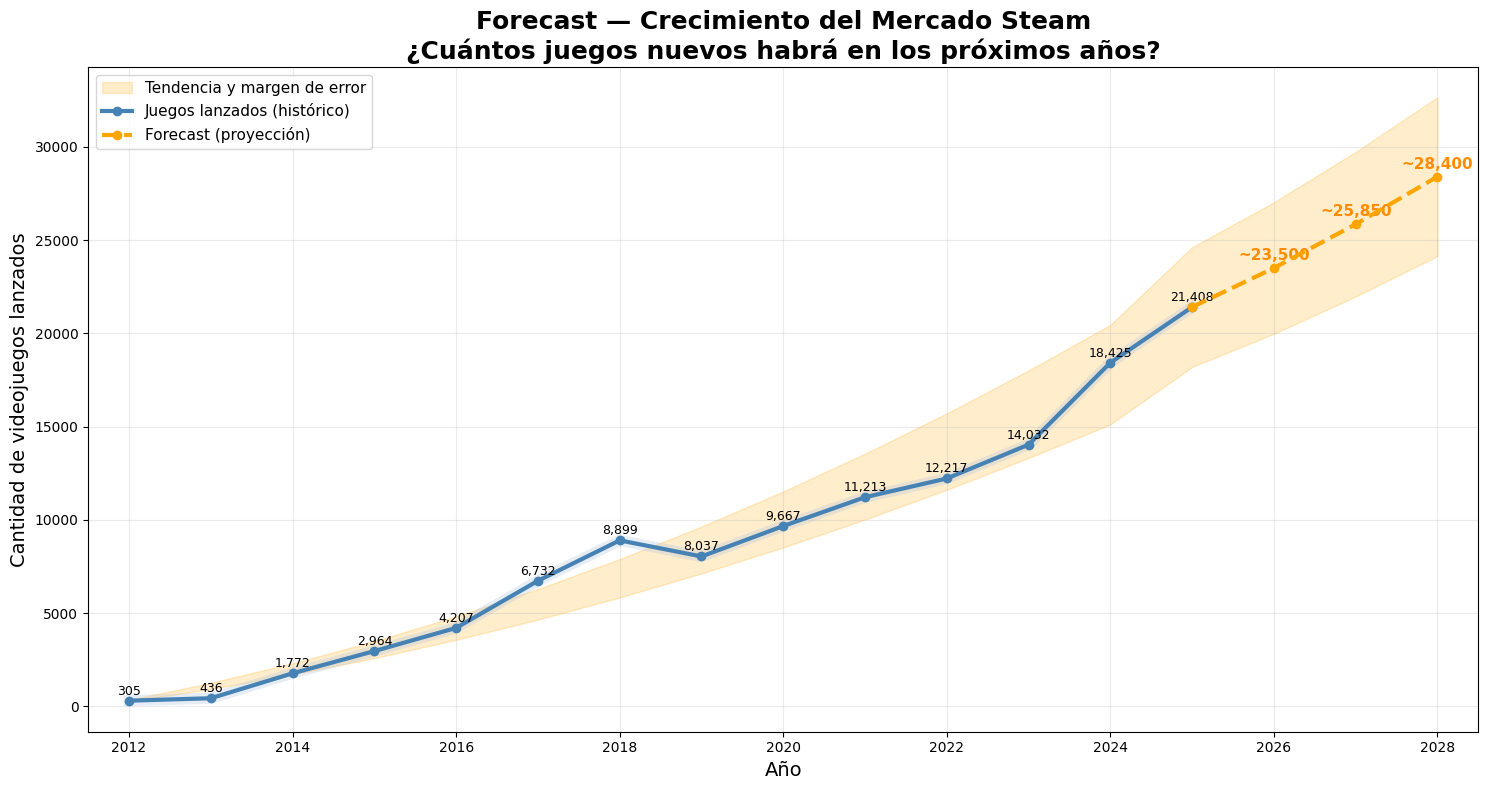

In [ ]:
# ==========================
# DATOS HISTÓRICOS ORIGINALES
# ==========================

años_original = [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
                 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
                 2022, 2023, 2024, 2025]

juegos_original = [60, 98, 170, 311, 260, 239, 305, 436,
                   1772, 2964, 4207, 6732, 8899, 8037,
                   9667, 11213, 12217, 14032, 18425, 21408]

# ==========================
# FORECAST
# ==========================

años_forecast = [2025, 2026, 2027, 2028]
forecast = [21408, 23500, 25850, 28400]

# Margen de error ±15%
error = np.array(forecast) * 0.15
lower = np.array(forecast) - error
upper = np.array(forecast) + error

# ==========================
# FILTRADO DE DATOS HISTÓRICOS DESDE 2012
# ==========================
start_year_display = 2012
idx_start_display = años_original.index(start_year_display)
años_display = años_original[idx_start_display:]
juegos_display = juegos_original[idx_start_display:]

# ==========================
# FIGURA
# ==========================

plt.figure(figsize=(15,8))

# ==========================
# BANDA DE TENDENCIA GENERAL Y FORECAST (unificada)
# ==========================

# Usando un ajuste polinómico de grado 2 para los datos filtrados para capturar mejor la tendencia
coef = np.polyfit(años_display, juegos_display, 2)
tendencia = np.poly1d(coef)

años_tendencia = np.arange(min(años_display), max(años_forecast)+1) # Rango completo para la sombra
valores_tendencia = tendencia(años_tendencia)

# Crear límites inferiores y superiores combinados para la sombra unificada
combined_lower_y = []
combined_upper_y = []

for year_val in años_tendencia:
    if year_val < años_forecast[0]:  # Parte de la tendencia histórica (antes de 2025)
        idx = list(años_tendencia).index(year_val)
        combined_lower_y.append(valores_tendencia[idx] * 0.85)
        combined_upper_y.append(valores_tendencia[idx] * 1.15)
    else:  # Parte del forecast (a partir de 2025)
        idx_forecast = años_forecast.index(year_val)
        combined_lower_y.append(lower[idx_forecast])
        combined_upper_y.append(upper[idx_forecast])

plt.fill_between(
    años_tendencia,
    combined_lower_y,
    combined_upper_y,
    color='orange',
    alpha=0.20,
    label='Tendencia y margen de error',
    zorder=0
)

# ==========================
# SOMBRA DE LA LÍNEA HISTÓRICA
# ==========================

plt.plot(
    años_display,
    juegos_display,
    linewidth=8,
    color='lightsteelblue',
    alpha=0.30,
    zorder=1
)

# ==========================
# LÍNEA HISTÓRICA
# ==========================

plt.plot(
    años_display,
    juegos_display,
    marker='o',
    linewidth=3,
    color='steelblue',
    label='Juegos lanzados (histórico)',
    zorder=3
)

# ==========================
# FORECAST
# ==========================

plt.plot(
    años_forecast,
    forecast,
    marker='o',
    linestyle='--',
    linewidth=3,
    color='orange',
    label='Forecast (proyección)',
    zorder=4
)

# ==========================
# ETIQUETAS HISTÓRICAS
# ==========================

for x, y in zip(años_display, juegos_display):
    plt.text(
        x,
        y + max(juegos_original)*0.015, # Usando el máximo original para una escala consistente
        f'{y:,}',
        ha='center',
        fontsize=9
    )

# ==========================
# ETIQUETAS FORECAST
# ==========================

for x, y in zip(años_forecast[1:], forecast[1:]):
    plt.text(
        x,
        y + max(juegos_original)*0.02, # Usando el máximo original para una escala consistente
        f'~{y:,}',
        ha='center',
        fontsize=11,
        color='darkorange',
        fontweight='bold'
    )

# ==========================
# FORMATO GENERAL
# ==========================

plt.title(
    'Forecast — Crecimiento del Mercado Steam\n¿Cuántos juegos nuevos habrá en los próximos años?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Año', fontsize=14)
plt.ylabel('Cantidad de videojuegos lanzados', fontsize=14)

plt.grid(True, alpha=0.25)

plt.legend(fontsize=11)
plt.xlim(start_year_display - 0.5, max(años_forecast) + 0.5) # Establecer límites del eje x para que comience desde 2012
plt.tight_layout()

plt.show()

    year  total  gratuitos  porcentaje
0   2010    284         14    4.929577
1   2011    376         21    5.585106
2   2012    565         36    6.371681
3   2013    822         51    6.204380
4   2014   1921        154    8.016658
5   2015   2963        316   10.664867
6   2016   4209        611   14.516512
7   2017   4989        857   17.177791
8   2018   5461       1015   18.586339
9   2019   5057        991   19.596599
10  2020   6135       1294   21.092095
11  2021   6774       1411   20.829643
12  2022   7265       1567   21.569167

FORECAST

2023: 25.12%
2024: 26.78%
2025: 28.44%


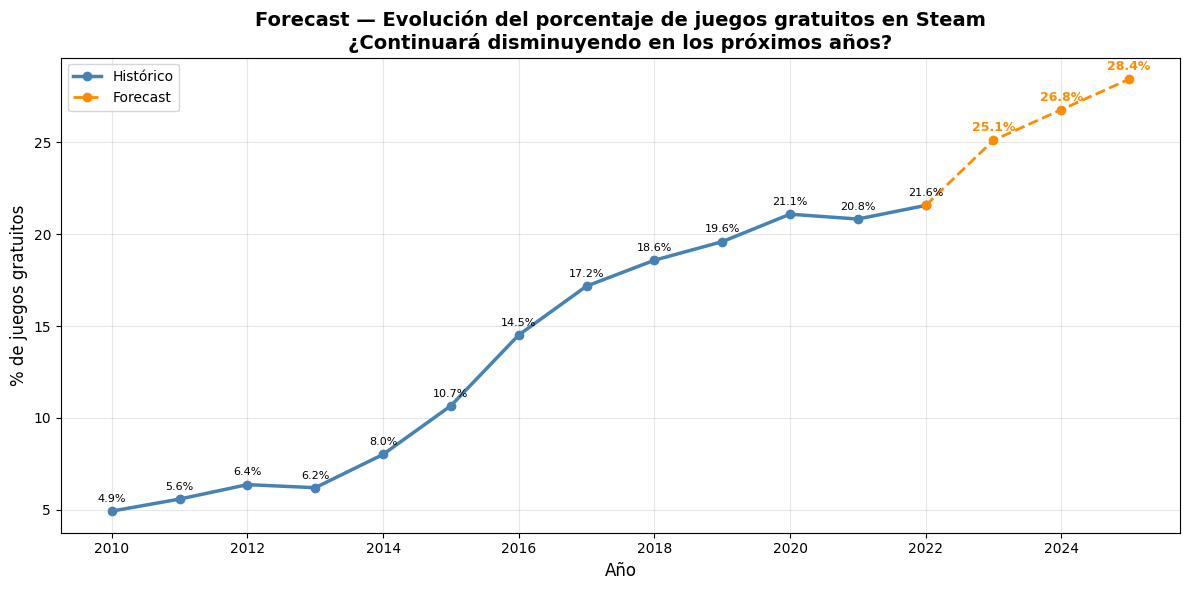

In [ ]:
# ============================================================
# FORECAST — PORCENTAJE DE JUEGOS GRATUITOS
# ============================================================

# Cargar dataset directamente para asegurar una versión original y llamarla df2_copy
df2_copy = pd.read_csv("games_dataset.csv", encoding="utf-8")

# Obtener año
df2_copy["year"] = pd.to_datetime(df2_copy["date_release"], errors="coerce").dt.year

# Nos quedamos con años razonables
df2_copy = df2_copy[df2_copy["year"].between(2010, 2022)]

# ------------------------------------------------
# Crear variable: juego gratuito
# ------------------------------------------------
# Se considera gratuito si el precio final es 0

df2_copy["gratis"] = df2_copy["price_final"] == 0

# ------------------------------------------------
# Calcular porcentaje de gratuitos por año
# ------------------------------------------------

resumen = (
    df2_copy.groupby("year")
      .agg(
          total=("gratis","count"),
          gratuitos=("gratis","sum")
      )
      .reset_index()
)

resumen["porcentaje"] = (
    resumen["gratuitos"] /
    resumen["total"] * 100
)

print(resumen)

# ===========================
# Modelo lineal
# ===========================

X = resumen["year"].values.reshape(-1,1)
y = resumen["porcentaje"].values

modelo = LinearRegression()
modelo.fit(X,y)

# Forecast

años_futuros = np.array([2023,2024,2025]).reshape(-1,1)

pred = modelo.predict(años_futuros)

print("\nFORECAST\n")

for a,p in zip([2023,2024,2025],pred):
    print(f"{a}: {p:.2f}%")

# ===========================
# Gráfico
# ===========================

plt.figure(figsize=(12,6))

# Histórico
plt.plot(
    resumen["year"],
    resumen["porcentaje"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
    label="Histórico"
)

# Forecast
plt.plot(
    [2022,2023,2024,2025],
    [resumen["porcentaje"].iloc[-1]] + list(pred),
    marker="o",
    linestyle="--",
    linewidth=2,
    color="darkorange",
    label="Forecast"
)

# Etiquetas

for x,y in zip(resumen["year"],resumen["porcentaje"]):
    plt.text(x,y+0.5,f"{y:.1f}%",ha="center",fontsize=8)

for x,y in zip([2023,2024,2025],pred):
    plt.text(x,y+0.5,f"{y:.1f}%",ha="center",
             fontsize=9,
             color="darkorange",
             fontweight="bold")

plt.grid(alpha=0.3)

plt.xlabel("Año",fontsize=12)
plt.ylabel("% de juegos gratuitos",fontsize=12)

plt.title(
    "Forecast — Evolución del porcentaje de juegos gratuitos en Steam\n"
    "¿Continuará disminuyendo en los próximos años?",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# FORECAST COMBINADO INTERACTIVO
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

#-----------------------
# Cargar datos (usando df2_copy del kernel state)
#-----------------------

df_combined_forecast = df2_copy.copy()

# df_combined_forecast ya contiene la columna 'year' y está filtrado entre 2010 y 2022
# debido al procesamiento en la celda 'ka0b92xVP2UA'.

#-----------------------
# Resumen
#-----------------------

resumen = (
    df_combined_forecast.groupby("year")
      .agg({
          "price_original":"mean",
          "discount":"mean"
      })
      .reset_index()
)

#-----------------------
# Modelos
#-----------------------

X = resumen[["year"]]

modelo_precio = LinearRegression()
modelo_desc = LinearRegression()

modelo_precio.fit(X,resumen["price_original"])
modelo_desc.fit(X,resumen["discount"])

años_futuros=[2023,2024,2025]

future=pd.DataFrame({
    "year":años_futuros
})

pred_precio=modelo_precio.predict(future)
pred_desc=modelo_desc.predict(future)

#=============================
# FIGURA
#=============================

fig=go.Figure()

# Histórico precio

fig.add_trace(
    go.Scatter(
        x=resumen["year"],
        y=resumen["price_original"],
        mode="lines+markers",
        name="Precio Original",
        line=dict(color="#00E5FF",width=4),
        marker=dict(size=10,color="#00E5FF"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Precio promedio: %{y:.2f}<extra></extra>"
    )
)

# Forecast precio

fig.add_trace(
    go.Scatter(
        x=[2022]+años_futuros,
        y=[resumen["price_original"].iloc[-1]]+list(pred_precio),
        mode="lines+markers",
        name="Forecast Precio",
        line=dict(color="#00E5FF",width=4,dash="dash"),
        marker=dict(size=10,color="#7DF9FF"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Forecast: %{y:.2f}<extra></extra>"
    )
)

# Histórico descuento

fig.add_trace(
    go.Scatter(
        x=resumen["year"],
        y=resumen["discount"],
        mode="lines+markers",
        name="Descuento",
        yaxis="y2",
        line=dict(color="#FF9800",width=4),
        marker=dict(size=10,color="#FFD54F"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Descuento: %{y:.2f}%<extra></extra>"
    )
)

# Forecast descuento

fig.add_trace(
    go.Scatter(
        x=[2022]+años_futuros,
        y=[resumen["discount"].iloc[-1]]+list(pred_desc),
        mode="lines+markers",
        name="Forecast Descuento",
        yaxis="y2",
        line=dict(color="#FF1744",width=4,dash="dash"),
        marker=dict(size=10,color="#FF4081"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Forecast: %{y:.2f}%<extra></extra>"
    )
)

#=============================
# Diseño
#=============================

fig.update_layout(

    title={
        "text":"<b>📊 Forecast Conjunto Steam</b><br><sup>Relación entre Precio Original y Descuento Promedio</sup>",
        "x":0.5,
        "y":0.925
    },

    template="plotly_dark",

    paper_bgcolor="#000000",
    plot_bgcolor="#000000",

    hovermode="x unified",

    xaxis=dict(
        title="Año",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.1)"
    ),

    yaxis=dict(
        title="Precio Original",
        color="#00E5FF"
    ),

    yaxis2=dict(
        title="Descuento (%)",
        overlaying="y",
        side="right",
        color="#FF9800"
    ),

    legend=dict(
        orientation="h",
        y=1.05,
        x=0.5,
        xanchor="center"
    ),

    font=dict(
        family="Arial",
        size=14,
        color="white"
    ),

    width=1200,
    height=650
)

fig.show()
